# Prediction of Product Sales

- Author: Walid Alsafadi

## Project Overview

## Load and Inspect Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sales_predictions_2023.csv")

1) How many rows and columns?

In [2]:
df.shape

(8523, 12)

In [3]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
df.tail()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


2) What are the datatypes of each variable?

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [6]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## Clean Data

3) Are there duplicates? If so, drop any duplicates.

In [7]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"New DataFrame shape: {df.shape}")

Number of duplicate rows: 0
New DataFrame shape: (8523, 12)


4) Identify missing values.

In [8]:
print(df.isnull().sum())

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


5) Address the missing values by using a placeholder value.

In [9]:
df['Item_Weight'] = df['Item_Weight'].fillna(0)
print(df.isnull().sum())

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


In [10]:
df['Outlet_Size'] = df['Outlet_Size'].fillna('Missing')
print(df.isnull().sum())

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


6) Confirm that there are no missing values after addressing them.

In [11]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

7) Find and fix any inconsistent categories of data (for example: fix cat, Cat, and cats so that they
are consistent).

In [12]:
print(df['Item_Fat_Content'].unique())

['Low Fat' 'Regular' 'low fat' 'LF' 'reg']


In [13]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(['low fat', 'LF'], 'Low Fat')
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace('reg', 'Regular')
print(df['Item_Fat_Content'].unique())

['Low Fat' 'Regular']


In [14]:
print(df['Item_Type'].unique())

['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household'
 'Baking Goods' 'Snack Foods' 'Frozen Foods' 'Breakfast'
 'Health and Hygiene' 'Hard Drinks' 'Canned' 'Breads' 'Starchy Foods'
 'Others' 'Seafood']


In [15]:
print(df['Outlet_Size'].unique())

['Medium' 'Missing' 'High' 'Small']


In [16]:
print(df['Outlet_Location_Type'].unique())

['Tier 1' 'Tier 3' 'Tier 2']


In [17]:
print(df['Outlet_Type'].unique())

['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']


8) For any numerical columns, obtain the summary statistics of each (min, max, mean).

In [18]:
df.describe().loc[['mean', 'min', 'max']]

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
mean,10.65059,0.066132,140.992782,1997.831867,2181.288914
min,0.00000,0.000000,31.290000,1985.000000,33.290000
max,21.35000,0.328391,266.888400,2009.000000,13086.964800


## Exploratory Visualizations

### Histograms for Numerical Features
These histograms help us see the shape and distribution of the numerical columns.

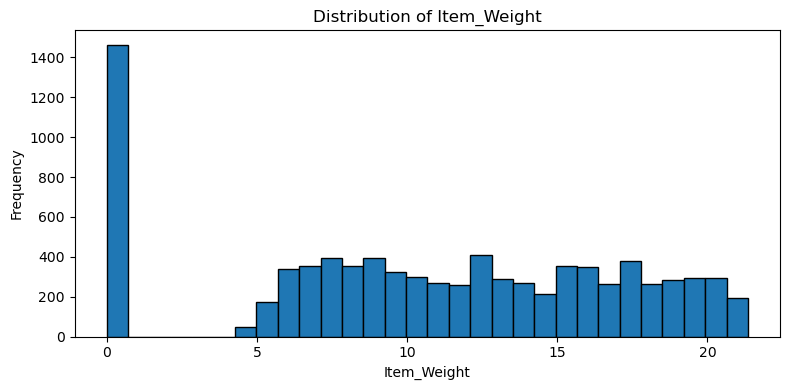

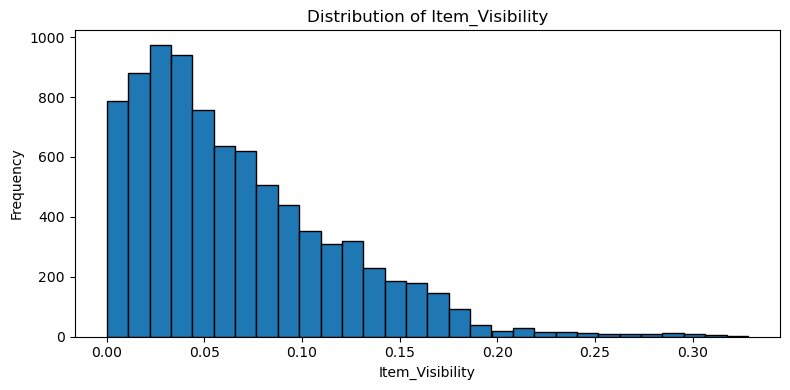

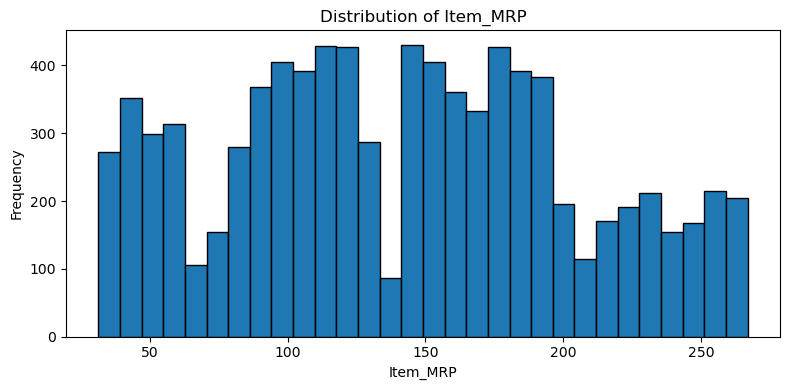

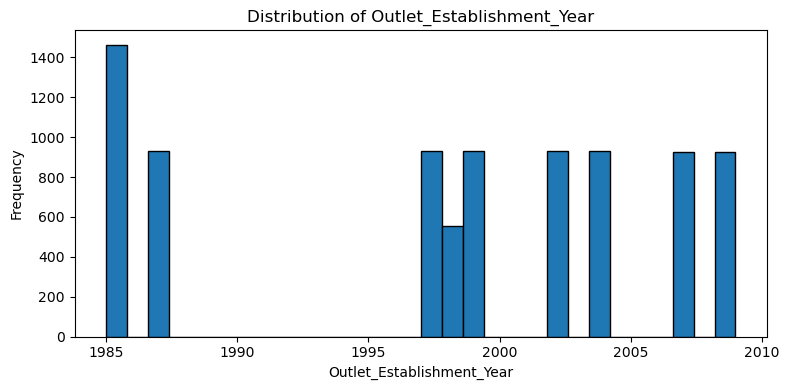

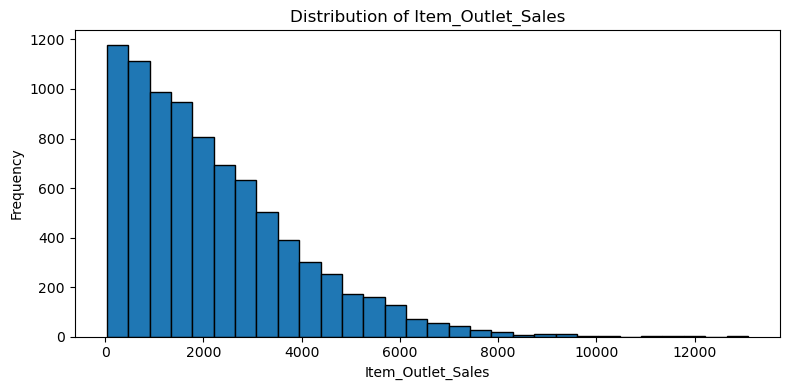

In [19]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=30, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Boxplots for Numerical Features
These boxplots help summarize the spread of the data and show possible outliers.

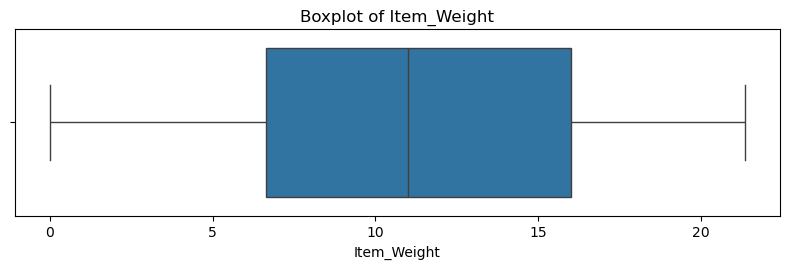

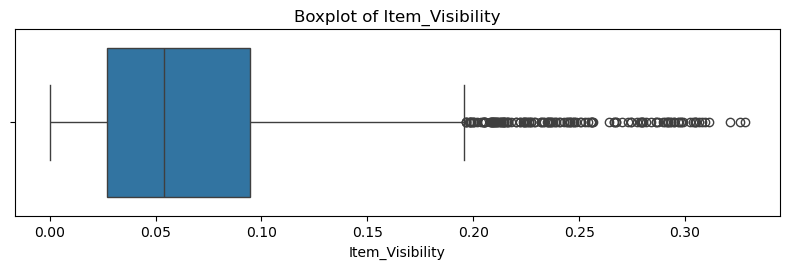

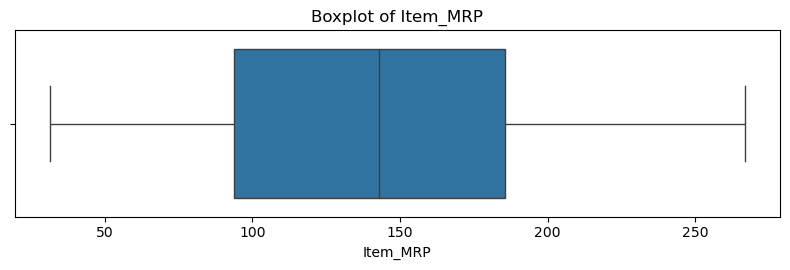

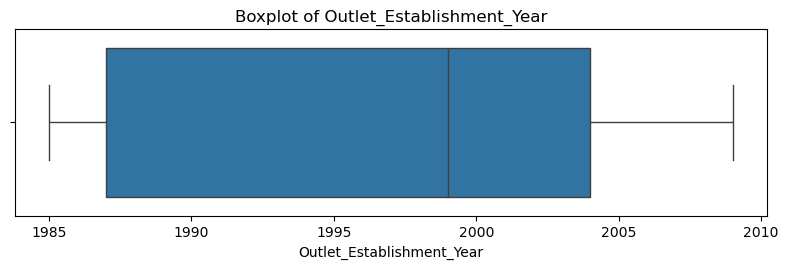

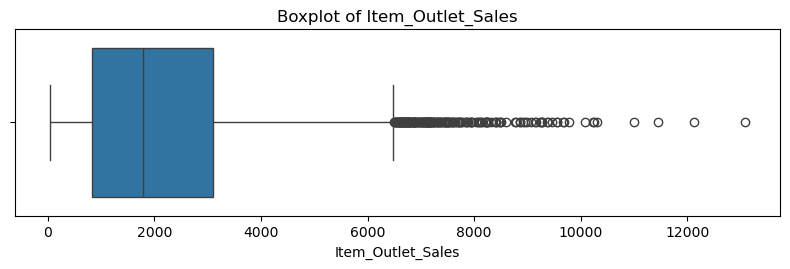

In [20]:
for col in numeric_cols:
    plt.figure(figsize=(8, 2.8))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

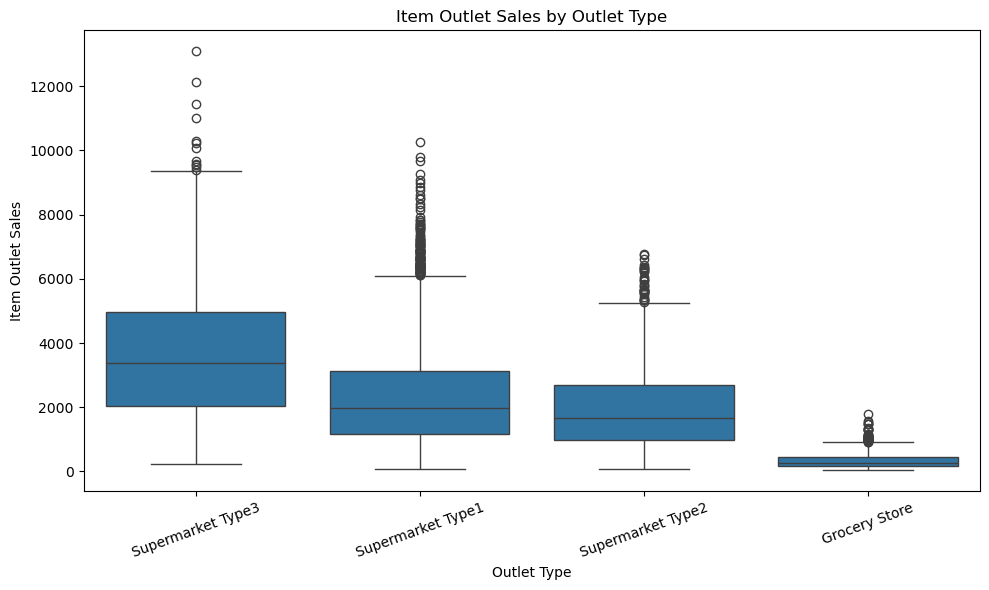

In [21]:
plt.figure(figsize=(10, 6))
order = df.groupby("Outlet_Type")["Item_Outlet_Sales"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Outlet_Type", y="Item_Outlet_Sales", order=order)
plt.title("Item Outlet Sales by Outlet Type")
plt.xlabel("Outlet Type")
plt.ylabel("Item Outlet Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("images/sales_by_outlet_type_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

### Countplots for Categorical Features
These countplots show how often each category in the dataset.

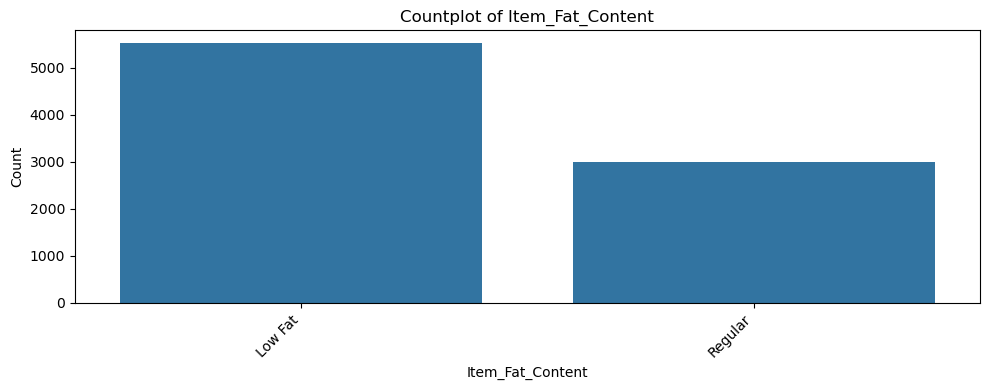

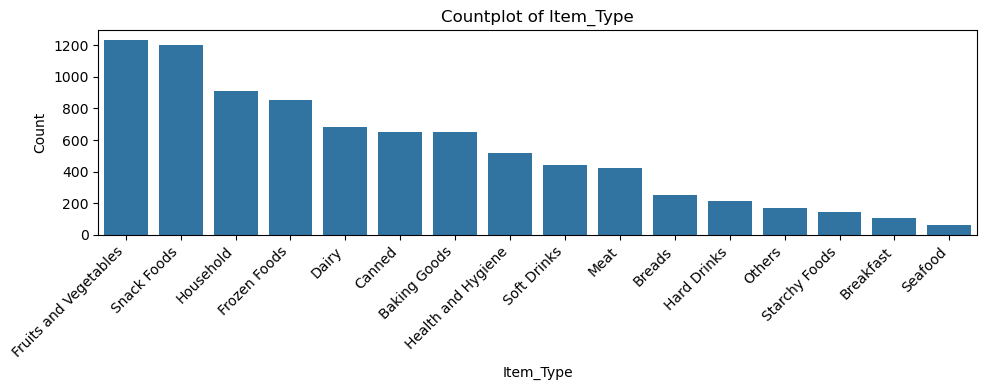

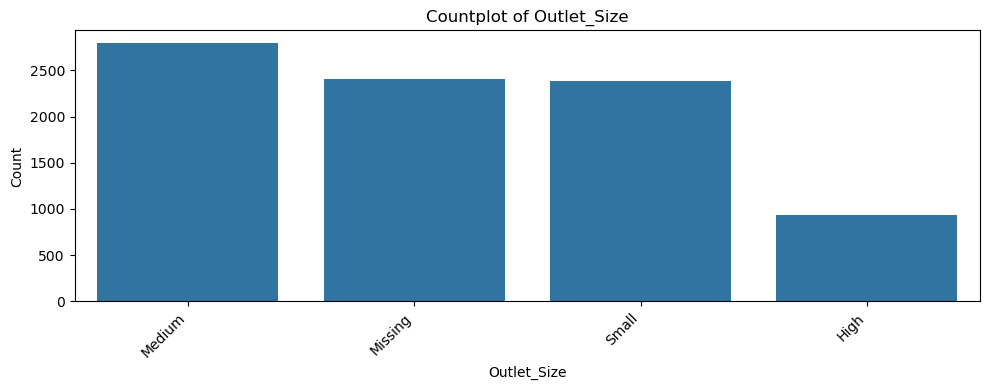

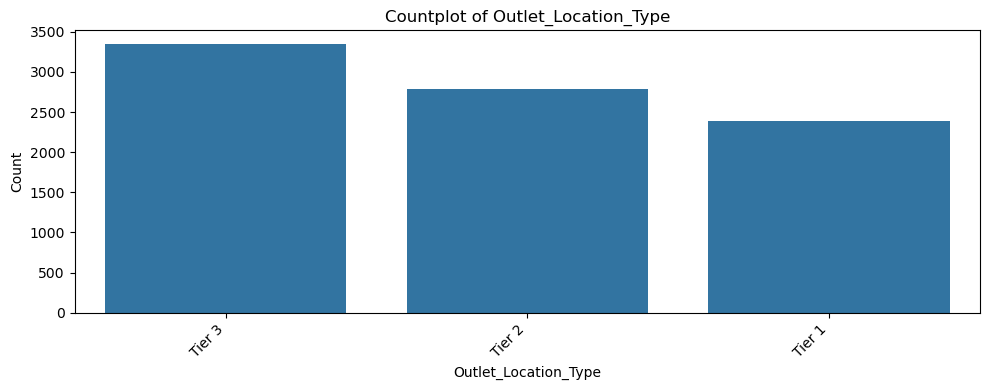

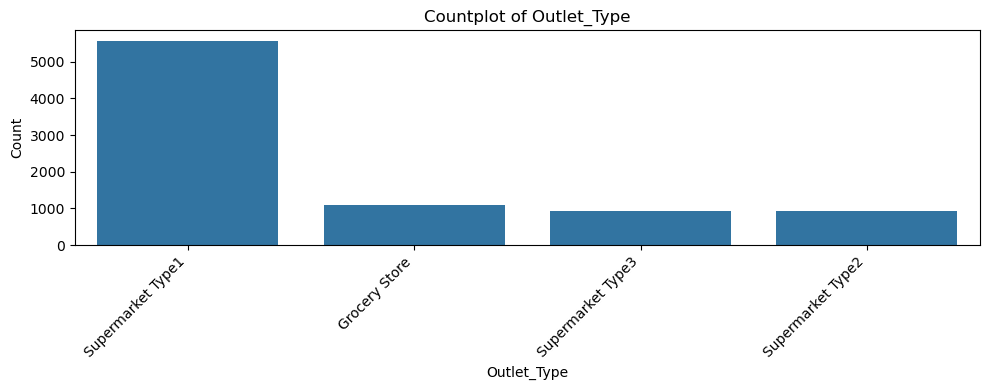

In [22]:
categorical_cols = [
    "Item_Fat_Content",
    "Item_Type",
    "Outlet_Size",
    "Outlet_Location_Type",
    "Outlet_Type"
]

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Countplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### Correlation Heatmap
This heatmap shows the correlation between the numerical features.

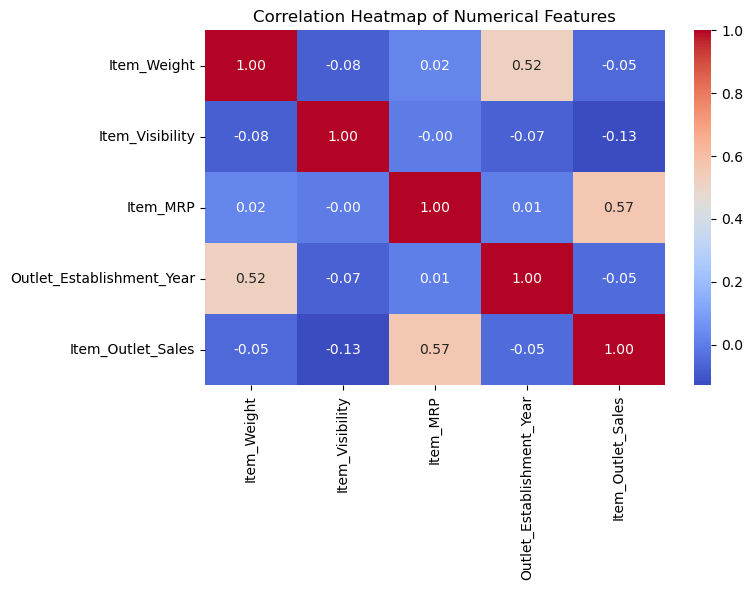

In [23]:
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## Feature Inspection

For this section, I reloaded the original dataset and removed the placeholder values used earlier so that missing values appear as true null values. This allows proper inspection of feature quality before machine learning.


In [24]:
# Fresh dataframe for Feature Inspection
df = pd.read_csv("sales_predictions_2023.csv")

# Drop duplicates
df = df.drop_duplicates()

# Fix inconsistent categories
df["Item_Fat_Content"] = df["Item_Fat_Content"].replace({
    "low fat": "Low Fat",
    "LF": "Low Fat",
    "reg": "Regular"
})

# Confirm null values are present
df.isna().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

### Helper Function

In [25]:
def feature_summary(df, col):
    print(f"Feature: {col}")
    print(f"Data type: {df[col].dtype}")
    print(f"Null values: {df[col].isna().sum()}")
    print(f"Null percentage: {df[col].isna().mean() * 100:.2f}%")
    print(f"Cardinality: {df[col].nunique(dropna=True)}")
    print(f"Most common value frequency: {df[col].value_counts(dropna=False, normalize=True).iloc[0] * 100:.2f}%")

### Item_Identifier

**Definition:** Product ID

In [26]:
feature_summary(df, "Item_Identifier")

Feature: Item_Identifier
Data type: object
Null values: 0
Null percentage: 0.00%
Cardinality: 1559
Most common value frequency: 0.12%


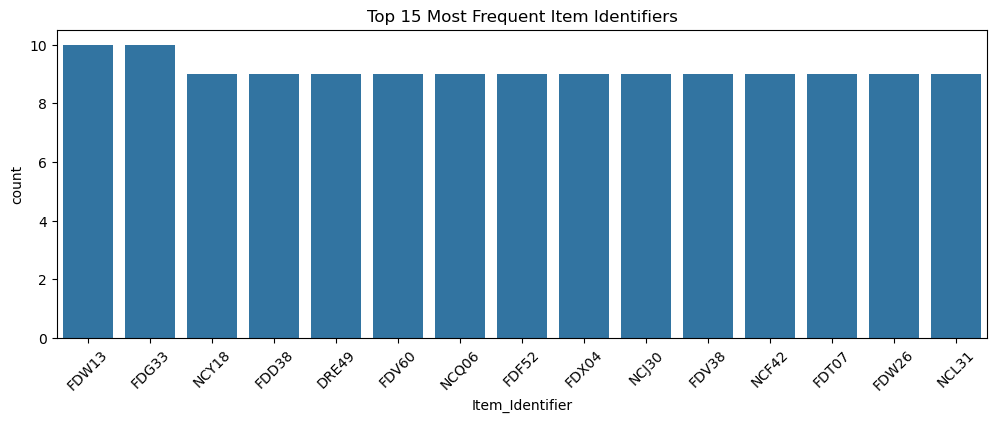

In [27]:
plt.figure(figsize=(12,4))
top_ids = df["Item_Identifier"].value_counts().head(15).index
sns.countplot(data=df[df["Item_Identifier"].isin(top_ids)], x="Item_Identifier", order=top_ids)
plt.title("Top 15 Most Frequent Item Identifiers")
plt.xticks(rotation=45)
plt.show()

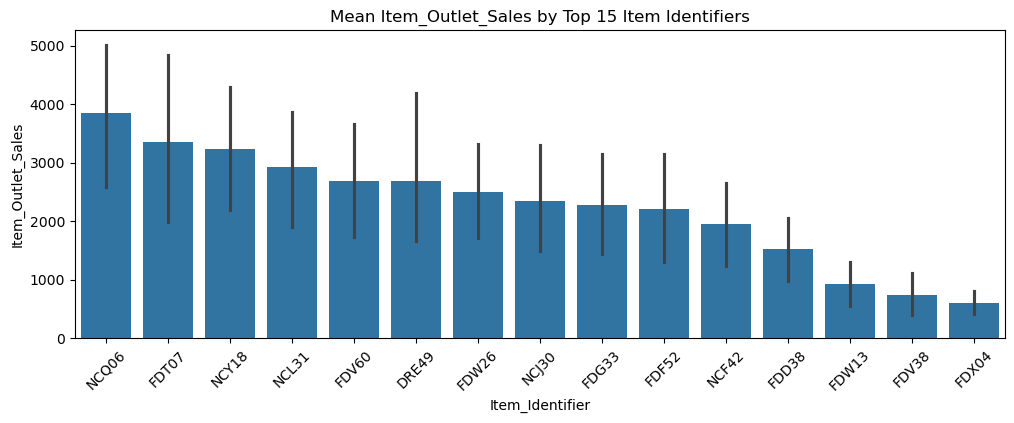

In [28]:
plt.figure(figsize=(12,4))
temp = df[df["Item_Identifier"].isin(top_ids)]
order = temp.groupby("Item_Identifier")["Item_Outlet_Sales"].mean().sort_values(ascending=False).index
sns.barplot(data=temp, x="Item_Identifier", y="Item_Outlet_Sales", order=order)
plt.title("Mean Item_Outlet_Sales by Top 15 Item Identifiers")
plt.xticks(rotation=45)
plt.show()

- **Type of feature:** Nominal
- **Null values:** 0 (0.00%)
- **What would I do with null values?** No action needed
- **Is the feature constant or quasi-constant?** No
- **Cardinality:** 1559, so it is high
- **Would we know this feature before the target is determined?** Yes
- **Is there a business reason to exclude it?** Maybe, because it is an ID field, not a real product property
- **Based on business understanding, would I expect it to be a predictor of the target?** Not strongly by itself
- **Does this feature appear to be a predictor of the target?** It may capture product-specific patterns, but as an ID it is not a strong feature to use directly

### Item_Weight

**Definition:** Weight of product

In [29]:
feature_summary(df, "Item_Weight")

Feature: Item_Weight
Data type: float64
Null values: 1463
Null percentage: 17.17%
Cardinality: 415
Most common value frequency: 17.17%


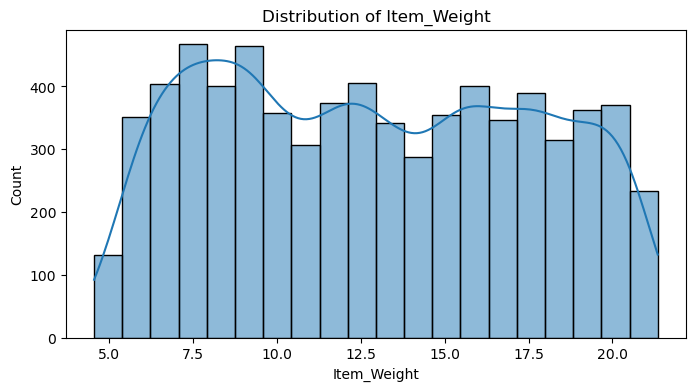

In [30]:
plt.figure(figsize=(8,4))
sns.histplot(df["Item_Weight"], kde=True)
plt.title("Distribution of Item_Weight")
plt.show()

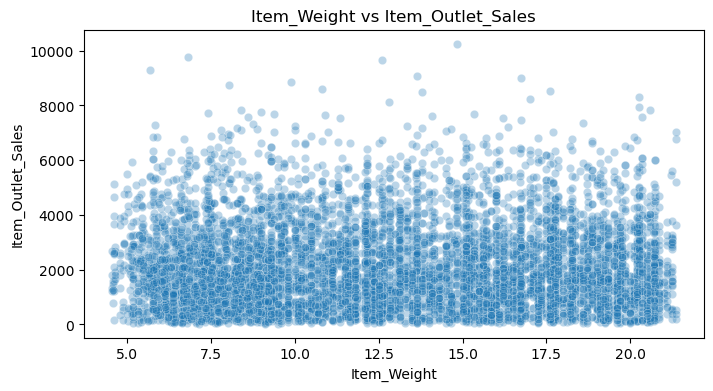

In [31]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x="Item_Weight", y="Item_Outlet_Sales", alpha=0.3)
plt.title("Item_Weight vs Item_Outlet_Sales")
plt.show()

- **Type of feature:** Numeric
- **Null values:** 1463 (17.17%)
- **What would I do with null values?** I would impute them, most likely with the median, because dropping that many rows would lose too much data
- **Is the feature constant or quasi-constant?** No
- **Cardinality:** 415, so it is high
- **Would we know this feature before the target is determined?** Yes
- **Is there a business reason to exclude it?** No
- **Based on business understanding, would I expect it to be a predictor of the target?** Maybe a weak predictor
- **Does this feature appear to be a predictor of the target?** It does not seem to have a strong relationship with sales

### Item_Fat_Content

**Definition:** Whether the product is low-fat or regular

In [32]:
feature_summary(df, "Item_Fat_Content")

Feature: Item_Fat_Content
Data type: object
Null values: 0
Null percentage: 0.00%
Cardinality: 2
Most common value frequency: 64.73%


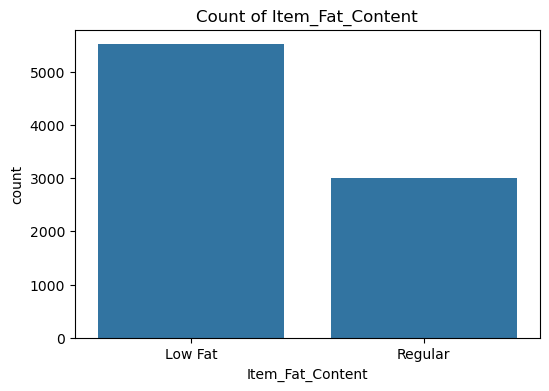

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Item_Fat_Content")
plt.title("Count of Item_Fat_Content")
plt.show()

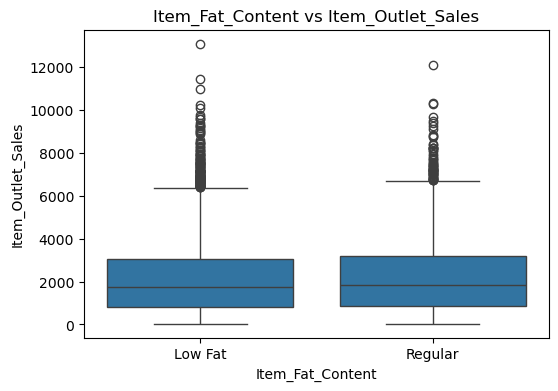

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Item_Fat_Content", y="Item_Outlet_Sales")
plt.title("Item_Fat_Content vs Item_Outlet_Sales")
plt.show()

- **Type of feature:** Nominal
- **Null values:** 0 (0.00%)
- **What would I do with null values?** No action needed
- **Is the feature constant or quasi-constant?** No
- **Cardinality:** 2, so it is low
- **Would we know this feature before the target is determined?** Yes
- **Is there a business reason to exclude it?** No
- **Based on business understanding, would I expect it to be a predictor of the target?** Possibly, but probably weak
- **Does this feature appear to be a predictor of the target?** The difference exists but does not look very large

### Item_Visibility

**Definition:** The percentage of total display area of all products in a store allocated to the particular product

In [35]:
feature_summary(df, "Item_Visibility")

Feature: Item_Visibility
Data type: float64
Null values: 0
Null percentage: 0.00%
Cardinality: 7880
Most common value frequency: 6.17%


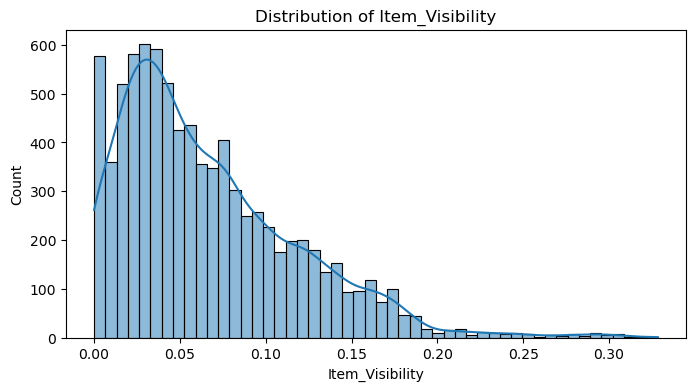

In [36]:
plt.figure(figsize=(8,4))
sns.histplot(df["Item_Visibility"], kde=True)
plt.title("Distribution of Item_Visibility")
plt.show()

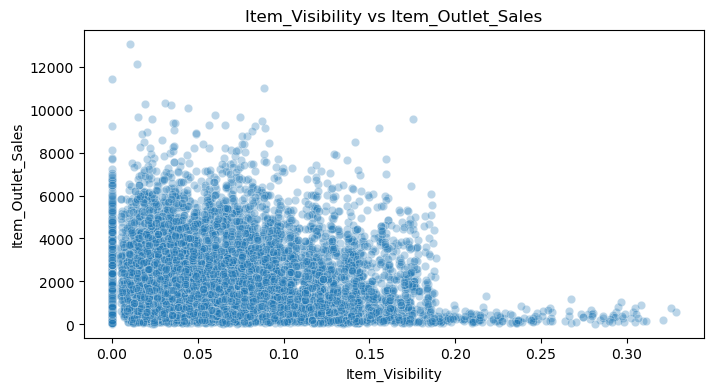

In [37]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x="Item_Visibility", y="Item_Outlet_Sales", alpha=0.3)
plt.title("Item_Visibility vs Item_Outlet_Sales")
plt.show()

- **Type of feature:** Numeric
- **Null values:** 0 (0.00%)
- **What would I do with null values?** No action needed
- **Is the feature constant or quasi-constant?** No
- **Cardinality:** 7880, so it is high
- **Would we know this feature before the target is determined?** Yes
- **Is there a business reason to exclude it?** No
- **Based on business understanding, would I expect it to be a predictor of the target?** Yes, because product visibility could affect sales
- **Does this feature appear to be a predictor of the target?** It seems to have some relationship with sales, but not a very strong one

### Item_Type

**Definition:** The category to which the product belongs

In [38]:
feature_summary(df, "Item_Type")

Feature: Item_Type
Data type: object
Null values: 0
Null percentage: 0.00%
Cardinality: 16
Most common value frequency: 14.46%


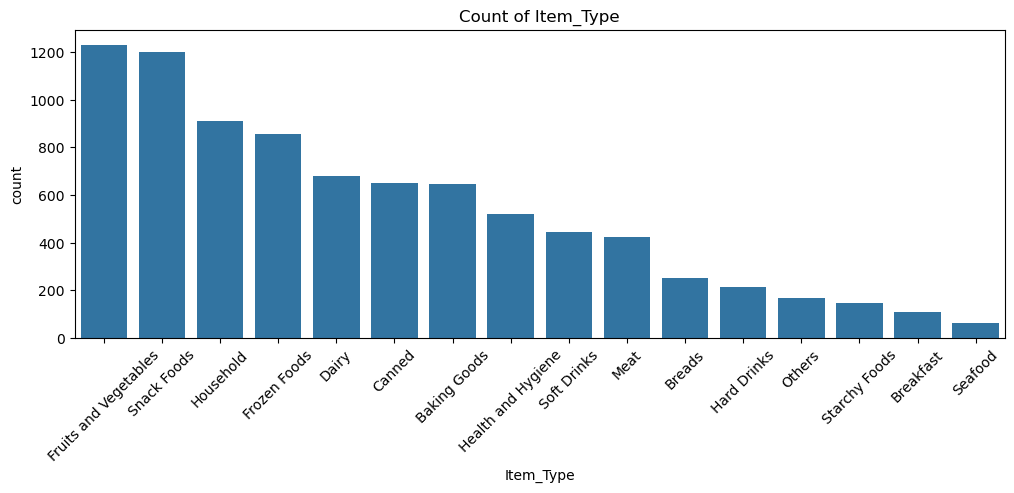

In [39]:
plt.figure(figsize=(12,4))
order = df["Item_Type"].value_counts().index
sns.countplot(data=df, x="Item_Type", order=order)
plt.title("Count of Item_Type")
plt.xticks(rotation=45)
plt.show()

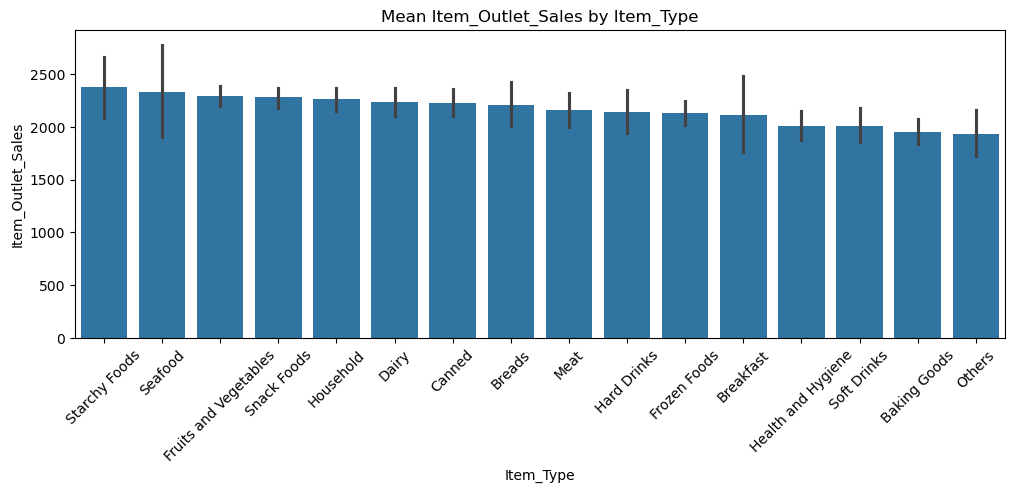

In [40]:
plt.figure(figsize=(12,4))
order = df.groupby("Item_Type")["Item_Outlet_Sales"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="Item_Type", y="Item_Outlet_Sales", order=order)
plt.title("Mean Item_Outlet_Sales by Item_Type")
plt.xticks(rotation=45)
plt.show()

- **Type of feature:** Nominal
- **Null values:** 0 (0.00%)
- **What would I do with null values?** No action needed
- **Is the feature constant or quasi-constant?** No
- **Cardinality:** 16, so it is high
- **Would we know this feature before the target is determined?** Yes
- **Is there a business reason to exclude it?** No
- **Based on business understanding, would I expect it to be a predictor of the target?** Yes, because product category can affect demand
- **Does this feature appear to be a predictor of the target?** Yes, some product categories clearly have different average sales

### Item_MRP

**Definition:** Maximum Retail Price (list price) of the product

In [41]:
feature_summary(df, "Item_MRP")

Feature: Item_MRP
Data type: float64
Null values: 0
Null percentage: 0.00%
Cardinality: 5938
Most common value frequency: 0.08%


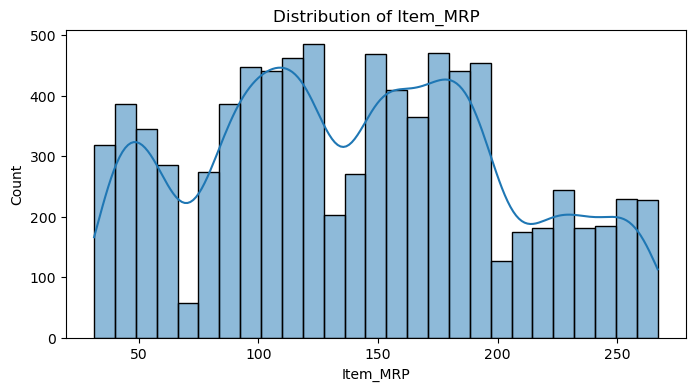

In [42]:
plt.figure(figsize=(8,4))
sns.histplot(df["Item_MRP"], kde=True)
plt.title("Distribution of Item_MRP")
plt.show()

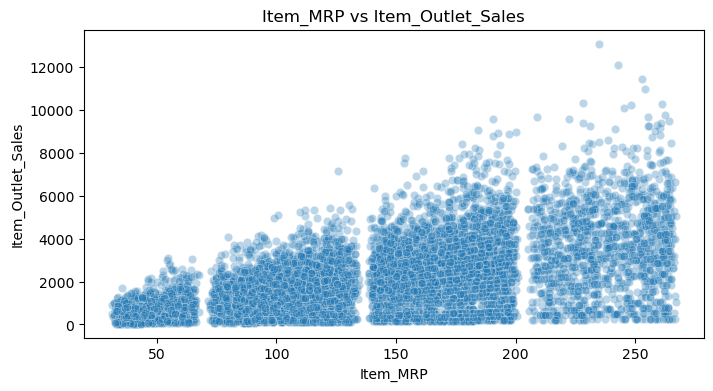

In [43]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x="Item_MRP", y="Item_Outlet_Sales", alpha=0.3)
plt.title("Item_MRP vs Item_Outlet_Sales")
plt.show()

- **Type of feature:** Numeric
- **Null values:** 0 (0.00%)
- **What would I do with null values?** No action needed
- **Is the feature constant or quasi-constant?** No
- **Cardinality:** 5938, so it is high
- **Would we know this feature before the target is determined?** Yes
- **Is there a business reason to exclude it?** No
- **Based on business understanding, would I expect it to be a predictor of the target?** Yes, strongly
- **Does this feature appear to be a predictor of the target?** Yes, this looks like one of the strongest predictors

### Outlet_Identifier

**Definition:** Store ID

In [44]:
feature_summary(df, "Outlet_Identifier")

Feature: Outlet_Identifier
Data type: object
Null values: 0
Null percentage: 0.00%
Cardinality: 10
Most common value frequency: 10.97%


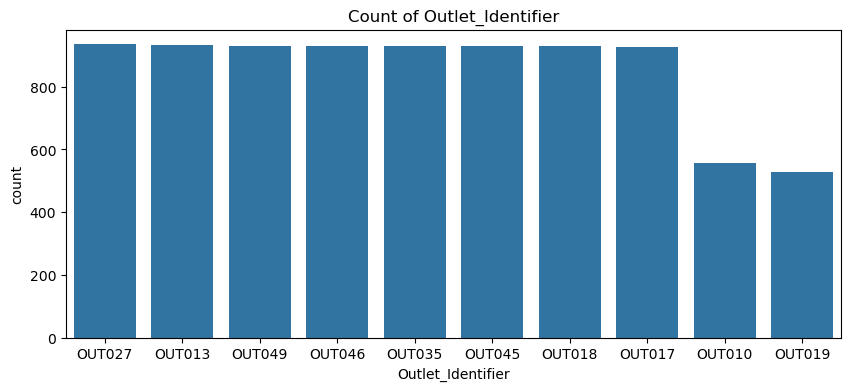

In [45]:
plt.figure(figsize=(10,4))
order = df["Outlet_Identifier"].value_counts().index
sns.countplot(data=df, x="Outlet_Identifier", order=order)
plt.title("Count of Outlet_Identifier")
plt.show()

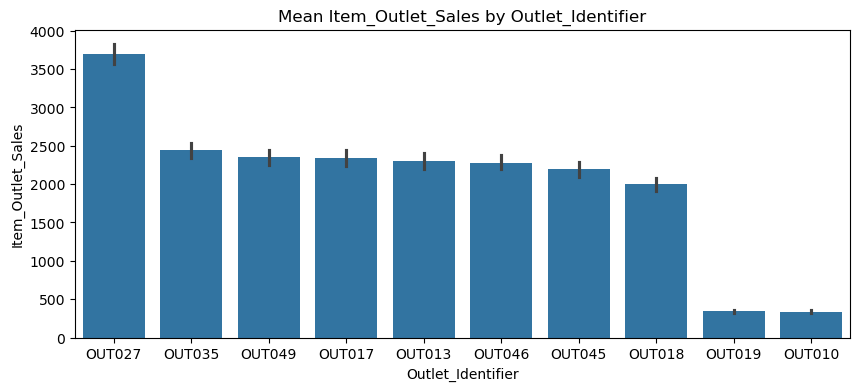

In [46]:
plt.figure(figsize=(10,4))
order = df.groupby("Outlet_Identifier")["Item_Outlet_Sales"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="Outlet_Identifier", y="Item_Outlet_Sales", order=order)
plt.title("Mean Item_Outlet_Sales by Outlet_Identifier")
plt.show()

- **Type of feature:** Nominal
- **Null values:** 0 (0.00%)
- **What would I do with null values?** No action needed
- **Is the feature constant or quasi-constant?** No
- **Cardinality:** 10, so it is not high based on the >10 rule
- **Would we know this feature before the target is determined?** Yes
- **Is there a business reason to exclude it?** Maybe, because it is an ID field, but outlet identity may still capture real store differences
- **Based on business understanding, would I expect it to be a predictor of the target?** Yes
- **Does this feature appear to be a predictor of the target?** Yes, average sales differ clearly across stores

### Outlet_Establishment_Year

**Definition:** The year in which store was established

In [47]:
feature_summary(df, "Outlet_Establishment_Year")

Feature: Outlet_Establishment_Year
Data type: int64
Null values: 0
Null percentage: 0.00%
Cardinality: 9
Most common value frequency: 17.17%


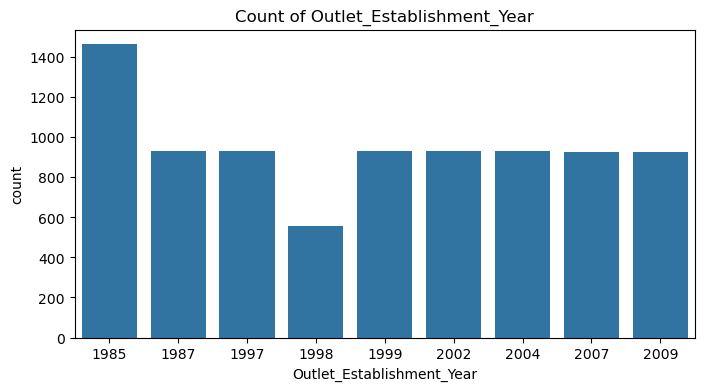

In [48]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Outlet_Establishment_Year")
plt.title("Count of Outlet_Establishment_Year")
plt.show()

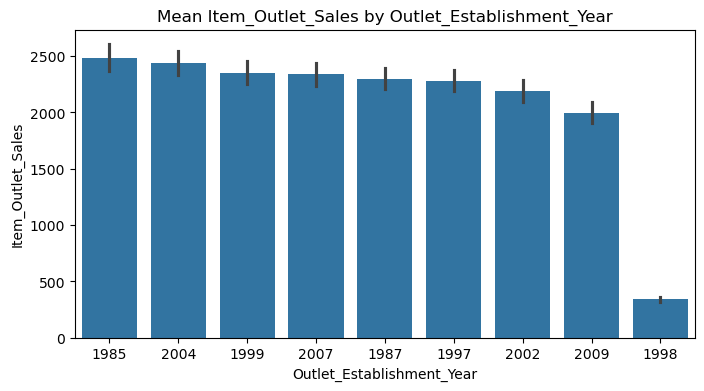

In [49]:
plt.figure(figsize=(8,4))
order = df.groupby("Outlet_Establishment_Year")["Item_Outlet_Sales"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="Outlet_Establishment_Year", y="Item_Outlet_Sales", order=order)
plt.title("Mean Item_Outlet_Sales by Outlet_Establishment_Year")
plt.show()

- **Type of feature:** Numeric
- **Null values:** 0 (0.00%)
- **What would I do with null values?** No action needed
- **Is the feature constant or quasi-constant?** No
- **Cardinality:** 9, so it is low
- **Would we know this feature before the target is determined?** Yes
- **Is there a business reason to exclude it?** No, although later it may be more useful to convert it into outlet age
- **Based on business understanding, would I expect it to be a predictor of the target?** Maybe
- **Does this feature appear to be a predictor of the target?** It does not look like a strong predictor by itself

### Outlet_Size

**Definition:** The size of the store in terms of ground area covered

In [50]:
feature_summary(df, "Outlet_Size")

Feature: Outlet_Size
Data type: object
Null values: 2410
Null percentage: 28.28%
Cardinality: 3
Most common value frequency: 32.77%


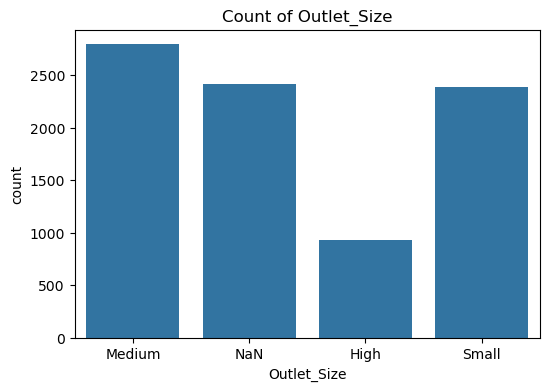

In [51]:
plt.figure(figsize=(6,4))
plot_df = df.copy()
plot_df["Outlet_Size"] = plot_df["Outlet_Size"].fillna("NaN")
sns.countplot(data=plot_df, x="Outlet_Size")
plt.title("Count of Outlet_Size")
plt.show()

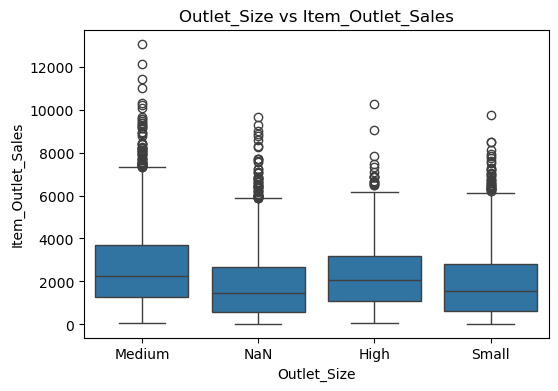

In [52]:
plt.figure(figsize=(6,4))
plot_df = df.copy()
plot_df["Outlet_Size"] = plot_df["Outlet_Size"].fillna("NaN")
sns.boxplot(data=plot_df, x="Outlet_Size", y="Item_Outlet_Sales")
plt.title("Outlet_Size vs Item_Outlet_Sales")
plt.show()

- **Type of feature:** Ordinal
- **Null values:** 2410 (28.28%)
- **What would I do with null values?** I would impute them, likely with the mode or using related outlet information, because dropping that many rows would remove too much data
- **Is the feature constant or quasi-constant?** No
- **Cardinality:** 3, so it is low
- **Would we know this feature before the target is determined?** Yes
- **Is there a business reason to exclude it?** No
- **Based on business understanding, would I expect it to be a predictor of the target?** Yes, because store size can affect sales
- **Does this feature appear to be a predictor of the target?** Yes, the sales distributions look different across outlet sizes

### Outlet_Location_Type

**Definition:** The type of area in which the store is located

In [53]:
feature_summary(df, "Outlet_Location_Type")

Feature: Outlet_Location_Type
Data type: object
Null values: 0
Null percentage: 0.00%
Cardinality: 3
Most common value frequency: 39.31%


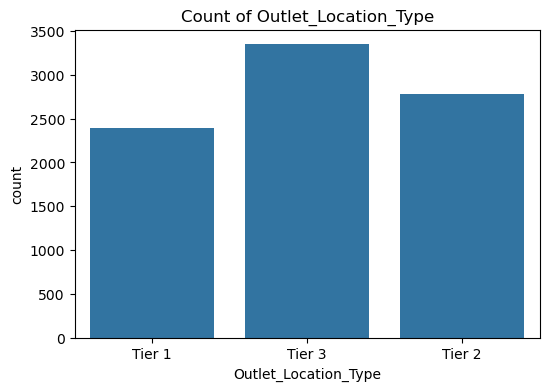

In [54]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Outlet_Location_Type")
plt.title("Count of Outlet_Location_Type")
plt.show()

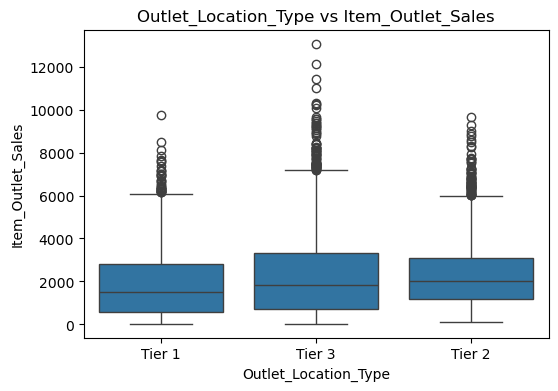

In [55]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Outlet_Location_Type", y="Item_Outlet_Sales")
plt.title("Outlet_Location_Type vs Item_Outlet_Sales")
plt.show()

- **Type of feature:** Ordinal
- **Null values:** 0 (0.00%)
- **What would I do with null values?** No action needed
- **Is the feature constant or quasi-constant?** No
- **Cardinality:** 3, so it is low
- **Would we know this feature before the target is determined?** Yes
- **Is there a business reason to exclude it?** No
- **Based on business understanding, would I expect it to be a predictor of the target?** Yes, because location can affect customer traffic and sales
- **Does this feature appear to be a predictor of the target?** Yes, the location tiers show visible differences in average sales

### Outlet_Type

**Definition:** Whether the outlet is a grocery store or some sort of supermarket

In [56]:
feature_summary(df, "Outlet_Type")

Feature: Outlet_Type
Data type: object
Null values: 0
Null percentage: 0.00%
Cardinality: 4
Most common value frequency: 65.43%


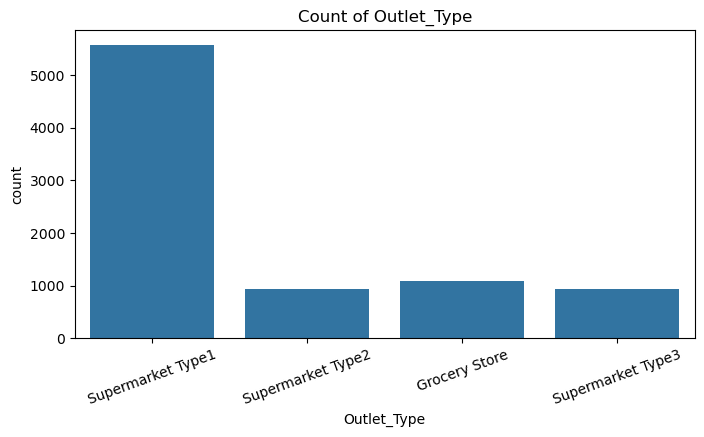

In [57]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Outlet_Type")
plt.title("Count of Outlet_Type")
plt.xticks(rotation=20)
plt.show()

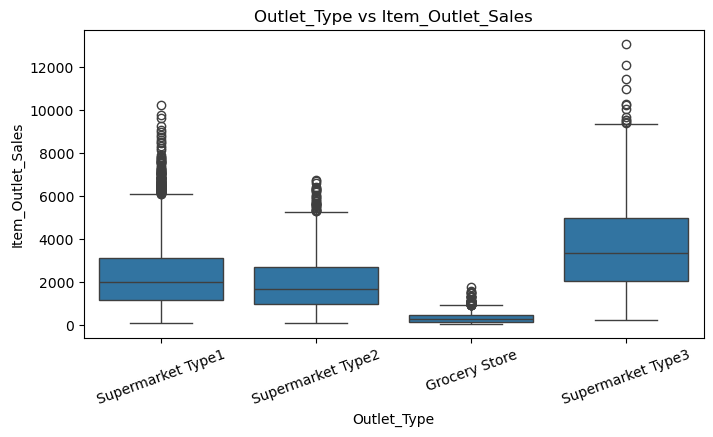

In [58]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Outlet_Type", y="Item_Outlet_Sales")
plt.title("Outlet_Type vs Item_Outlet_Sales")
plt.xticks(rotation=20)
plt.show()

- **Type of feature:** Nominal
- **Null values:** 0 (0.00%)
- **What would I do with null values?** No action needed
- **Is the feature constant or quasi-constant?** No
- **Cardinality:** 4, so it is low
- **Would we know this feature before the target is determined?** Yes
- **Is there a business reason to exclude it?** No
- **Based on business understanding, would I expect it to be a predictor of the target?** Yes, strongly
- **Does this feature appear to be a predictor of the target?** Yes, this looks like an important predictor because sales differ a lot by outlet type

### Feature Inspection Summary

After inspecting all features, the main missing-value problems are in `Item_Weight` and `Outlet_Size`, so these will likely need imputation in the next stage instead of dropping rows. Some features such as `Item_MRP`, `Outlet_Type`, `Outlet_Identifier`, `Outlet_Size`, `Outlet_Location_Type`, and `Item_Type` appear to be stronger predictors of `Item_Outlet_Sales`. Other features like `Item_Weight` and `Outlet_Establishment_Year` seem weaker on their own. ID features such as `Item_Identifier` and `Outlet_Identifier` may contain patterns, but they should be treated carefully because they are identifiers rather than true descriptive features.

## Sales Prediction

For Part 5, I used a fresh copy of the original dataset to avoid leakage. I cleaned only the issues that are safe to fix before the train-test split: duplicate rows and inconsistent category labels. Then I defined the features and target, dropped `Item_Identifier` due to its high cardinality, split the data, and built a preprocessing pipeline so that missing-value imputation happens **after** the split.

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [60]:
# Load a fresh copy of the original data
sales_df = pd.read_csv("sales_predictions_2023.csv")

# Clean only the issues that are safe to handle before splitting
sales_df = sales_df.drop_duplicates()
sales_df["Item_Fat_Content"] = sales_df["Item_Fat_Content"].replace({
    "low fat": "Low Fat",
    "LF": "Low Fat",
    "reg": "Regular"
})

sales_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


### Define Features and Target

In [61]:
X = sales_df.drop(columns=["Item_Outlet_Sales", "Item_Identifier"])
y = sales_df["Item_Outlet_Sales"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target:", y.name)

X shape: (8523, 10)
y shape: (8523,)
Target: Item_Outlet_Sales


### Train-Test Split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (6392, 10)
Testing features shape: (2131, 10)
Training target shape: (6392,)
Testing target shape: (2131,)


### Preprocessing Object

In [63]:
# Separate columns by type
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
ordinal_features = ["Outlet_Size", "Outlet_Location_Type"]
nominal_features = [
    col for col in X_train.select_dtypes(include="object").columns
    if col not in ordinal_features
]

print("Numeric features:", numeric_features)
print("Ordinal categorical features:", ordinal_features)
print("Nominal categorical features:", nominal_features)

Numeric features: ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']
Ordinal categorical features: ['Outlet_Size', 'Outlet_Location_Type']
Nominal categorical features: ['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Type']


In [64]:
# Define the category order for ordinal features
ordinal_categories = [
    ["Small", "Medium", "High"],
    ["Tier 1", "Tier 2", "Tier 3"]
]

# Build transformers
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("ord", ordinal_transformer, ordinal_features),
    ("nom", nominal_transformer, nominal_features)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['Item_Weight', 'Item_Visibility', 'Item_MRP',
                                  'Outlet_Establishment_Year']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(categories=[['Small',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Tier '
                                                                              '1',
                                                                              'Tier '
                                                                              '2',
                                                                              'Tier '
                                                                              '3']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['Outlet_Size', 'Outlet_Location_Type']),
                                ('nom',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Item_Fat_Content', 'Item_Type',
                                  'Outlet_Identifier', 'Outlet_Type'])])

### Baseline Models

In [65]:
def evaluate_regression(model, X_train, X_test, y_train, y_test):
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    train_preds = pipe.predict(X_train)
    test_preds = pipe.predict(X_test)
    
    results = {
        "Train MAE": mean_absolute_error(y_train, train_preds),
        "Test MAE": mean_absolute_error(y_test, test_preds),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
        "Train R2": r2_score(y_train, train_preds),
        "Test R2": r2_score(y_test, test_preds)
    }
    
    return pipe, pd.Series(results).round(3)

In [66]:
linreg_model, linreg_results = evaluate_regression(
    LinearRegression(), X_train, X_test, y_train, y_test
)
linreg_results

Train MAE      847.129
Test MAE       804.120
Train RMSE    1139.104
Test RMSE     1092.863
Train R2         0.562
Test R2          0.567
dtype: float64

In [67]:
rf_model, rf_results = evaluate_regression(
RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1),
    X_train, X_test, y_train, y_test
)
rf_results

Train MAE      295.067
Test MAE       769.013
Train RMSE     423.109
Test RMSE     1104.167
Train R2         0.940
Test R2          0.558
dtype: float64

In [68]:
model_comparison = pd.DataFrame({
    "Linear Regression": linreg_results,
    "Random Forest": rf_results
})
model_comparison

,Linear Regression,Random Forest
Train MAE,847.129,295.067
Test MAE,804.120,769.013
Train RMSE,1139.104,423.109
Test RMSE,1092.863,1104.167
Train R2,0.562,0.940
Test R2,0.567,0.558


### Sales Prediction Summary

Insights
- The data includes numeric and categorical features.
- `Item_Identifier` was dropped because it has high cardinality.
- Missing values were handled after the train-test split to avoid leakage.

Results
- Linear Regression: Test R² = 0.567, Test RMSE = 1092.863
- Random Forest: Test R² = 0.558, Test RMSE = 1104.167
- Linear Regression performed slightly better on the test set.

Conclusion
- Linear Regression is the better model for this part.
- Random Forest appears to overfit the training data.
- The preprocessing and evaluation workflow is reliable.

## CRISP-DM Phase 4 - Modeling

### 1) Linear Regression Model
The linear regression model was already built in Part 5, so I will reuse its results here as the baseline model.

In [69]:
linreg_results

Train MAE      847.129
Test MAE       804.120
Train RMSE    1139.104
Test RMSE     1092.863
Train R2         0.562
Test R2          0.567
dtype: float64

In [70]:
def r2_fit_comment(results, model_name):
    train_r2 = results["Train R2"]
    test_r2 = results["Test R2"]
    gap = train_r2 - test_r2

    if gap > 0.10:
        status = "This model is overfitting because the training R² is much higher than the test R²."
    elif gap < -0.05:
        status = "This model may be unstable because the test R² is higher than the training R²."
    else:
        if train_r2 < 0.60 and test_r2 < 0.60:
            status = "This model is not heavily overfitting, but it may be a little underfit because both scores are moderate."
        else:
            status = "This model looks fairly balanced between training and test data."

    print(f"{model_name}")
    print(f"Train R²: {train_r2:.3f}")
    print(f"Test R²: {test_r2:.3f}")
    print(f"Gap: {gap:.3f}")
    print(status)

In [71]:
r2_fit_comment(linreg_results, "Linear Regression")

Linear Regression
Train R²: 0.562
Test R²: 0.567
Gap: -0.005
This model is not heavily overfitting, but it may be a little underfit because both scores are moderate.


### 2) Default Random Forest Model
Now I will build a default Random Forest model and compare it with linear regression.


In [72]:
rf_default_model, rf_default_results = evaluate_regression(
    RandomForestRegressor(random_state=42),
    X_train,
    X_test,
    y_train,
    y_test
)

rf_default_results

Train MAE      296.456
Test MAE       767.302
Train RMSE     427.194
Test RMSE     1103.878
Train R2         0.938
Test R2          0.558
dtype: float64

In [73]:
r2_fit_comment(rf_default_results, "Default Random Forest")

Default Random Forest
Train R²: 0.938
Test R²: 0.558
Gap: 0.380
This model is overfitting because the training R² is much higher than the test R².


In [74]:
baseline_comparison = pd.DataFrame({
    "Linear Regression": linreg_results,
    "Default Random Forest": rf_default_results
})

baseline_comparison

,Linear Regression,Default Random Forest
Train MAE,847.129,296.456
Test MAE,804.120,767.302
Train RMSE,1139.104,427.194
Test RMSE,1092.863,1103.878
Train R2,0.562,0.938
Test R2,0.567,0.558


### 3) Tune the Random Forest with GridSearchCV
I will tune at least two hyperparameters for the Random Forest model, then fit one final model on the full training set using the best parameters.


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
rf_grid_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=rf_grid_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation R²:", round(grid_search.best_score_, 3))

Best parameters: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Best cross-validation R²: 0.589


In [ ]:
best_rf_params = {
    key.replace("model__", ""): value
    for key, value in grid_search.best_params_.items()
}

best_rf_params

{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}

In [ ]:
rf_tuned_model, rf_tuned_results = evaluate_regression(
    RandomForestRegressor(random_state=42, **best_rf_params),
    X_train,
    X_test,
    y_train,
    y_test
)

rf_tuned_results

Train MAE      662.113
Test MAE       738.482
Train RMSE     938.385
Test RMSE     1063.183
Train R2         0.702
Test R2          0.590
dtype: float64

In [ ]:
r2_fit_comment(rf_tuned_results, "Tuned Random Forest")

Tuned Random Forest
Train R²: 0.702
Test R²: 0.590
Gap: 0.112
This model is overfitting because the training R² is much higher than the test R².


In [ ]:
full_model_comparison = pd.DataFrame({
    "Linear Regression": linreg_results,
    "Default Random Forest": rf_default_results,
    "Tuned Random Forest": rf_tuned_results
})

full_model_comparison

,Linear Regression,Default Random Forest,Tuned Random Forest
Train MAE,847.129,296.456,662.113
Test MAE,804.120,767.302,738.482
Train RMSE,1139.104,427.194,938.385
Test RMSE,1092.863,1103.878,1063.183
Train R2,0.562,0.938,0.702
Test R2,0.567,0.558,0.590


In [ ]:
comparison_table = pd.DataFrame({
    "Model": ["Linear Regression", "Default Random Forest", "Tuned Random Forest"],
    "Train R2": [
        linreg_results["Train R2"],
        rf_default_results["Train R2"],
        rf_tuned_results["Train R2"]
    ],
    "Test R2": [
        linreg_results["Test R2"],
        rf_default_results["Test R2"],
        rf_tuned_results["Test R2"]
    ],
    "Test RMSE": [
        linreg_results["Test RMSE"],
        rf_default_results["Test RMSE"],
        rf_tuned_results["Test RMSE"]
    ],
    "Test MAE": [
        linreg_results["Test MAE"],
        rf_default_results["Test MAE"],
        rf_tuned_results["Test MAE"]
    ]
})

comparison_table.sort_values(by=["Test R2", "Test RMSE"], ascending=[False, True])

,Model,Train R2,Test R2,Test RMSE,Test MAE
2,Tuned Random Forest,0.702,0.590,1063.183,738.482
0,Linear Regression,0.562,0.567,1092.863,804.120
1,Default Random Forest,0.938,0.558,1103.878,767.302


### CRISP-DM Phase 5 - Evaluation

Overall, I recommend **Tuned Random Forest**.

- This model had the best test performance compared with the other models.
- Its test R² is **0.590**, which means it explains about **59.0%** of the variation in product sales on unseen data.
- I would also report **RMSE = 1063.183** to a non-technical stakeholder because RMSE is in the same unit as sales and it penalizes larger prediction errors more strongly.
- Looking at the training and test scores helps show whether the model is overfitting or underfitting. A large gap means overfitting, while low scores on both sets suggest underfitting.
